
### B.4. Implement the K-Means algorithm and visualize the data in 2-D space before clustering. Compare  the  performance  of  the  K-means  clustering  algorithm  with  the  DBSCAN algorithm.

## K-Means Clustering

K-Means is an unsupervised partition-based clustering algorithm that groups a given dataset into \(K\) distinct, non-overlapping clusters. The objective of K-Means is to minimize the intra-cluster variance, also known as the within-cluster sum of squares (WCSS).

### Objective Function

Given a dataset $X = x_1, x_2, \ldots, x_n$ where each data point $(x_i \in \mathbb{R}^d)$, K-Means aims to partition the data into $K$ clusters $C = C_1, C_2, \ldots, C_K$ by minimizing the following objective function:

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2
$$

where $\mu_k$ is the centroid (mean) of cluster $C_k$, defined as:

$$
\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i
$$

### Algorithm

The K-Means algorithm follows an iterative optimization procedure consisting of the following steps:

1. **Initialization:** Randomly initialize \(K\) centroids from the data space.
2. **Assignment Step:** Assign each data point \(x_i\) to the nearest centroid using the Euclidean distance:
   
   $$
   C_k = \{x_i : \|x_i - \mu_k\| \leq \|x_i - \mu_j\|, \forall j \in \{1, \ldots, K\}\}
   $$

3. **Update Step:** Recompute each centroid \(\mu_k\) as the mean of all data points assigned to cluster \(C_k\).
4. **Convergence Check:** Repeat the assignment and update steps until the centroids no longer change significantly or a maximum number of iterations is reached.

### Convergence and Complexity

K-Means is guaranteed to converge to a local minimum of the objective function, though not necessarily the global minimum. The computational complexity of the algorithm is \(O(nKdI)\), where \(n\) is the number of data points, \(d\) is the dimensionality of the data, \(K\) is the number of clusters, and \(I\) is the number of iterations.

### Advantages and Limitations

**Advantages:**
- Simple and easy to implement
- Computationally efficient for large datasets
- Performs well for spherical and well-separated clusters

**Limitations:**
- Requires the number of clusters \(K\) to be specified in advance
- Sensitive to initial centroid selection
- Performs poorly on non-spherical clusters and noisy datasets


## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is a density-based unsupervised clustering algorithm that groups data points based on the density of points in a given region. Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance and is capable of identifying arbitrarily shaped clusters as well as noise points.

### Core Concepts

DBSCAN classifies data points into three categories:

- **Core points:** A point is a core point if it has at least `MinPts` data points within a radius $\varepsilon$.
- **Border points:** A point that lies within the $\varepsilon$ -neighborhood of a core point but has fewer than `MinPts` neighbors.
- **Noise points:** A point that is neither a core point nor a border point and does not belong to any cluster.

### Parameters

DBSCAN relies on two key parameters:

- $\varepsilon (epsilon)$: The radius that defines the neighborhood around a data point.
- `MinPts`: The minimum number of points required within the $\varepsilon$ -neighborhood to form a dense region.

### Algorithm

The DBSCAN algorithm proceeds as follows:

1. Select an unvisited data point.
2. Retrieve all points within its $\varepsilon$-neighborhood.
3. If the number of neighbors is less than `MinPts`, label the point as noise.
4. If the point is a core point, create a new cluster and recursively expand it by including all density-reachable points.
5. Repeat the process until all points have been visited.

### Density Reachability

A point $x_j$ is said to be **density-reachable** from point $x_i$ if there exists a sequence of points $x_i, x_1, \ldots, x_j$ such that each point lies within the $\varepsilon$-neighborhood of the previous point and all intermediate points are core points.

### Advantages and Limitations

**Advantages:**
- Does not require the number of clusters to be predefined
- Can discover clusters of arbitrary shape
- Effectively identifies noise and outliers

**Limitations:**
- Sensitive to the choice of \(\varepsilon\) and `MinPts`
- Struggles with datasets of varying density
- Performance degrades in high-dimensional spaces


In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [81]:
class KMean:
    def __init__(self,k=3):
        self.k = k
        self.centroid = None

    @staticmethod
    def euclidean_dist(data_point_1, centroids):
        return np.sqrt(np.sum((centroids - data_point_1)**2,axis=1))

    def fit(self, X, maxiterate = 200):
        self.centroid = np.random.uniform(np.amin(X,axis=0),np.amax(X,axis=0),
                                            size = (self.k, X.shape[1]))
        
        for _ in range(maxiterate):
            Y = []
            for data_point in X:
                distances = KMean.euclidean_dist(data_point,self.centroid)
                cluster_num = np.argmin(distances)
                Y.append(cluster_num)
            
            Y = np.array(Y)

            cluster_index = []

            for i in range(self.k):
                cluster_index.append(np.argwhere(Y == i))
            
            cluster_centres = []

            for i, indices in enumerate(cluster_index):
                if len(indices) == 0:
                    cluster_centres.append(self.centroid[i])
                else: 
                    cluster_centres.append(np.mean(X[indices], axis=0)[0])
            
            if np.max(self.centroid - np.array(cluster_centres)) < 0.00001:
                break
            else:
                self.centroid = np.array(cluster_centres)
        
        return Y

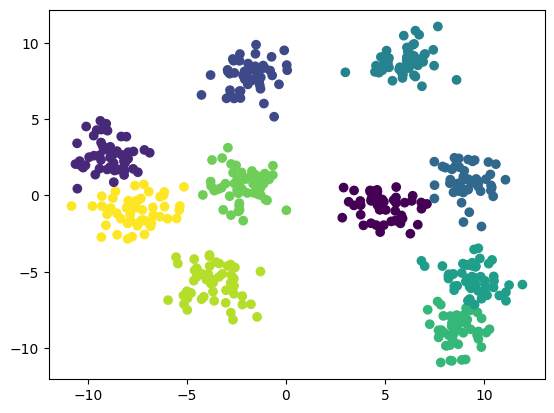

In [169]:
from sklearn.datasets import make_blobs

data = make_blobs(n_samples = 500, n_features = 2, centers = 10)
random_points = data[0]

kmean = KMean(k=10)
labels = kmean.fit(random_points)

# print(labels)

plt.scatter(random_points[:,0],random_points[:,1],c=labels)
plt.show()

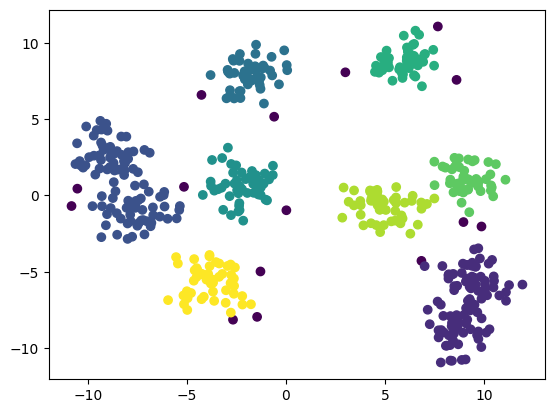

DBSCAN clusters: 8
Noise points: 15


In [170]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1, min_samples=5)
db_labels = dbscan.fit_predict(random_points)

# print(db_labels)

plt.scatter(random_points[:,0], random_points[:,1], c=db_labels)
plt.show()

unique_labels = set(db_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

print("DBSCAN clusters:", n_clusters)
print("Noise points:", list(db_labels).count(-1))


In [171]:
from sklearn.metrics import silhouette_score

sil_kmeans = silhouette_score(random_points, labels)
print("Silhouette Score (K-Means):", sil_kmeans)

# DBSCAN: only if >1 cluster (excluding noise)
if n_clusters > 1:
    sil_dbscan = silhouette_score(
        random_points[db_labels != -1],
        db_labels[db_labels != -1]
    )
    print("Silhouette Score (DBSCAN):", sil_dbscan)


Silhouette Score (K-Means): 0.6286115891061353
Silhouette Score (DBSCAN): 0.6573279358358654


In [173]:
from sklearn.metrics import adjusted_rand_score

true_labels = data[1]

ari_kmeans = adjusted_rand_score(true_labels, labels)
ari_dbscan = adjusted_rand_score(true_labels, db_labels)

print("ARI (K-Means):", ari_kmeans)
print("ARI (DBSCAN):", ari_dbscan)


ARI (K-Means): 0.9619647433012843
ARI (DBSCAN): 0.7734346204967748


| Aspect                | K-Means            | DBSCAN                 |
| --------------------- | ------------------ | ---------------------- |
| Number of clusters    | Must be predefined | Automatically detected |
| Cluster shape         | Assumes spherical  | Arbitrary shapes       |
| Noise handling        | ❌ No               | ✅ Yes                  |
| Parameter sensitivity | Initialization     | eps, min_samples       |
| Performance on blobs  | Excellent          | Depends on eps         |
